<a href="https://colab.research.google.com/github/Nikhil0264/Collab_special/blob/main/Hugging_face_02_code_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets

In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
from huggingface_hub import HfApi
api = HfApi()

In [ ]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
classifier("I've been waiting for a HuggingFace course my whole life.")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9598046541213989}]

In [ ]:
classifier("I've been hating you.")

[{'label': 'NEGATIVE', 'score': 0.9957868456840515}]

In [ ]:
from google.colab import userdata
token = userdata.get('token')

In [ ]:
from transformers import pipeline

classifier = pipeline(
    task="text-classification",
    model="vennify/t5-base-grammar-correction",
    token = token,
)
classifier(
    "This is a course about the Transformers library",
)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] T5ForSequenceClassification LOAD REPORT from: vennify/t5-base-grammar-correction
Key                                 | Status     | 
------------------------------------+------------+-
lm_head.weight                      | UNEXPECTED | 
classification_head.dense.weight    | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[{'label': 'LABEL_0', 'score': 0.6326247453689575}]

In [ ]:
from transformers import pipeline
classifier = pipeline(
    task="text-classification",
    model="textattack/bert-base-uncased-QNLI"
)
input_prompt = "what is the capital of India? Delhi is capital of India"
print(classifier(input_prompt))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'LABEL_0', 'score': 0.5902863144874573}]


In [ ]:
from transformers import pipeline
classifier = pipeline(
    task="zero-shot-classification",
    model="aammari/setfit-zero-shot-classification-pbsp-p3-freq"
)
text = "this is live lecture about hugging face of science"
candidate_labels = ["education","politics","business"]
output = classifier(text,candidate_labels)

print(output['labels'][0])
print(output['scores'][0])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] MPNetForSequenceClassification LOAD REPORT from: aammari/setfit-zero-shot-classification-pbsp-p3-freq
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


education
0.33361998200416565


In [ ]:
from transformers import pipeline

summarizer = pipeline(
    task="Summarization",
    model="facebook/bart-large-cnn"
)

text = """Education is one of the most important things in our lives. It gives us knowledge, builds our confidence, and helps us understand the world around us. Education also teaches us good values, discipline, and responsibility. It helps us achieve our goals and prepares us for a better future. Therefore, every person should have the opportunity to receive a good education."""

result = summarizer(
    text,
    max_length=50,
    min_length=20,
    do_sample=False
)

print(result[0]["summary_text"])


KeyError: "Unknown task Summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
from transformers import image_transforms
from PIL import Image
original_image = Image.open("/common.jpg").convert("RGB")

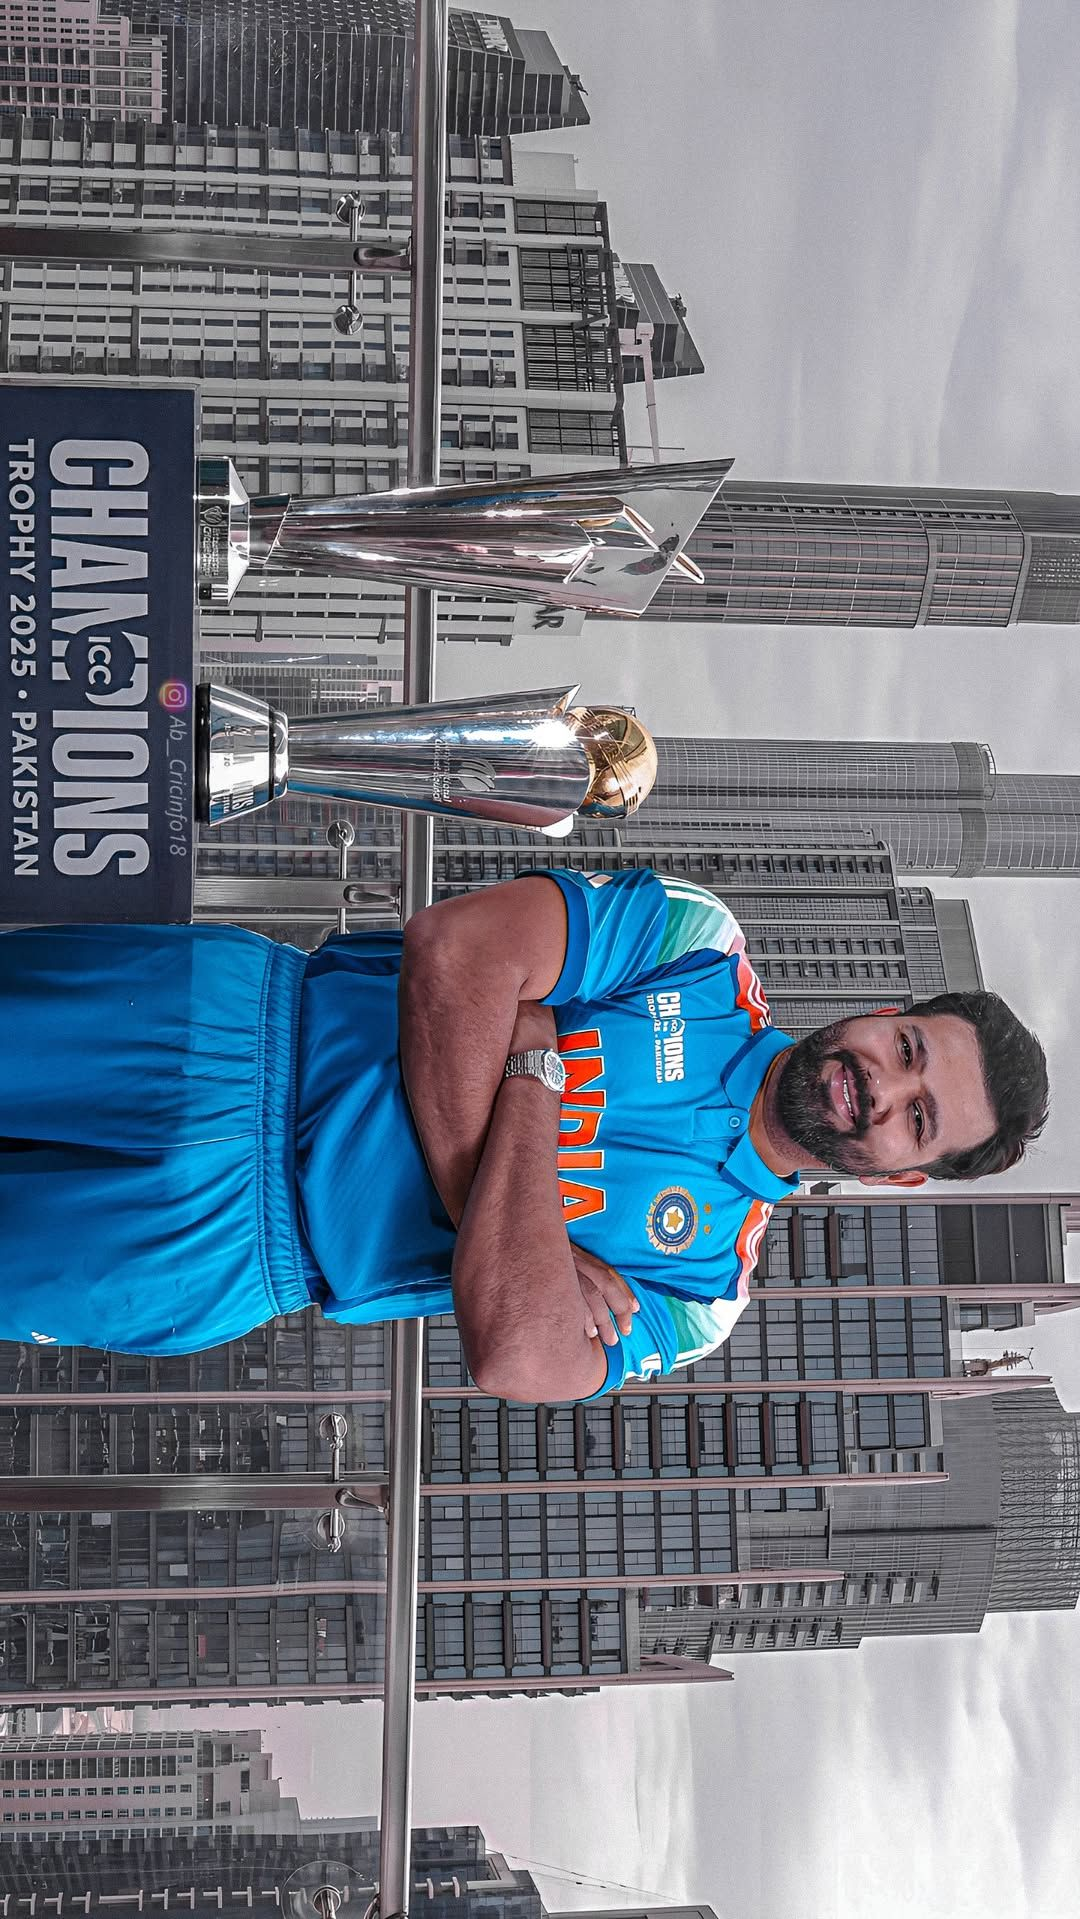

In [ ]:
original_image

In [ ]:
import numpy as np
image_array = np.array(original_image)
print(image_array)

[[[154 141 148]
  [152 139 146]
  [150 135 142]
  ...
  [169 169 181]
  [169 169 181]
  [169 169 181]]

 [[126 115 121]
  [125 114 120]
  [129 116 123]
  ...
  [172 172 184]
  [172 172 184]
  [172 172 184]]

 [[133 127 131]
  [129 123 127]
  [130 121 126]
  ...
  [174 174 186]
  [174 174 186]
  [174 174 186]]

 ...

 [[ 45  43  48]
  [ 43  41  46]
  [ 37  35  40]
  ...
  [246 246 246]
  [246 246 246]
  [245 245 245]]

 [[ 59  57  62]
  [ 51  49  54]
  [ 39  37  42]
  ...
  [246 246 246]
  [245 245 245]
  [244 244 244]]

 [[ 35  33  38]
  [ 63  61  66]
  [ 70  68  73]
  ...
  [246 246 246]
  [244 244 244]
  [242 242 242]]]


In [ ]:
image_array.shape

(1919, 1080, 3)

array([[[131,  80,  77],
        [131,  80,  77],
        [130,  79,  76],
        ...,
        [  9,  98, 158],
        [ 85, 198, 255],
        [ 12, 149, 204]],

       [[132,  81,  78],
        [131,  80,  77],
        [131,  80,  77],
        ...,
        [  0,  78, 139],
        [ 78, 188, 249],
        [ 26, 161, 217]],

       [[132,  81,  78],
        [131,  80,  77],
        [131,  80,  77],
        ...,
        [  0,  69, 135],
        [ 72, 178, 240],
        [ 41, 171, 229]],

       ...,

       [[156,  98,  97],
        [154,  96,  95],
        [153,  95,  94],
        ...,
        [  0,  42,  96],
        [  3,  48, 103],
        [  6,  49, 102]],

       [[159, 101, 100],
        [161, 103, 102],
        [159, 101, 100],
        ...,
        [  3,  52, 108],
        [  0,  41,  99],
        [  0,  47, 105]],

       [[148,  92,  93],
        [150,  94,  95],
        [153,  97,  98],
        ...,
        [  0,  52, 112],
        [  2,  56, 118],
        [  2,  58, 119]]], dtype=uint8)
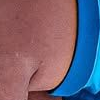

In [ ]:
image_transforms.center_crop(
    image = image_array,
    size = (100,100)
)

In [ ]:
from transformers import pipeline

classifier = pipeline(
    task="image-classification",
    model="facebook/convnext-large-224"
)

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  791MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  791MB            

model.safetensors: downloading bytes:           |  0.00B            